In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import nltk
import numpy as np
import seaborn as sns
from matplotlib.ticker import FuncFormatter
from nltk.corpus import cess_esp
from collections import Counter
from nltk.stem import SnowballStemmer
from nltk.stem import WordNetLemmatizer
from IPython.display import display, Image

Uncomment the following lines of code to install `omw`, `cess_esp`, `punkt`, `wordnet`:

In [2]:
#nltk.download('omw')  # Descargar el recurso WordNet en español
#nltk.download('cess_esp')  # Descargar el corpus CESS en español (etiquetado POS)
#nltk.download('punkt')
#nltk.download('wordnet')

In [3]:
import sys
#sys.path.insert(0, '/Users/eduardomorenoortiz/Desktop/ITAM/nanook/nlp_nanook/src') # LOCAL
sys.path.insert(0, r'C:\Users\eduardo.moreno\OneDrive - NEORIS\Desktop\courses\nlp\nlp_nanook\src') # Windows
from utils.utils import get_corpus_N_gram

### Manual configuration

In case `nltk.download('omw')`, `nltk.download('cess_esp')` and/or `nltk.download('punkt')` response were **False**, then download following models from the next [link](http://www.nltk.org/nltk_data/):
- Model: *Extended Open Multilingual WordNet*, ID: *extended_omw*
- Model: *CESS-ESP Treebank*, ID: *cess_esp*
- Model: *Punkt Tokenizer Models*, ID: *punkt*
- Model: *WordNet*, ID: *wordnet*

Once files are downloaded move them to:
- *extended_omw*, *cess_esp*: */env_nanook/lib/nltk_data/tokenizers* 
- *punkt*: */env_nanook/lib/nltk_data/tokenizers*
- *wordnet*: */env_nanook/lib/nltk_data/tokenizers/corpora*

Update the following line of code with the specific path for folder `nltk_data`

In [4]:
#nltk.data.path.append('/Users/eduardomorenoortiz/Desktop/ITAM/nanook/nlp_nanook/env_nlp_nanook/lib/python3.11/site-packages/nltk/nltk_data') # Uncomment if necessary

# Load data

In [5]:
df_clean = pd.read_pickle(r'..\..\..\data\preprocessed\clean_text_nanook.pkl')

In [6]:
df_clean.head()

,index,Facebook Id,Likes at Posting,Post Created,Type,Total Interactions,Likes,Comments,Shares,Love,...,Angry,Care,Message,Image Text,Link Text,Description,score,messageChar_length,messageWords_length,Message_clean
0,0,153630631414604,NaN,2016-01-05 20:55:17 CST,Photo,"7,836",7266,442,63,51,...,0,2,A LOS NACIDOS ENTRE 1970 Y 1987 Somos una gene...,NaN,NaN,NaN,36.28,4329,720,a los nacidos entre 1970 y 1987 somos una gene...
1,1,344760762323803,NaN,2018-03-25 20:22:33 CST,Photo,"12,530",2946,44,9025,357,...,17,18,PORQUE VOTARE POR GUSTAVO PETRO Hoy quiero com...,NaN,NaN,NaN,338.65,3577,603,porque votare por gustavo petro hoy quiero com...
2,2,663135523805166,NaN,2018-04-26 15:23:31 CDT,Photo,"3,727",2137,77,917,583,...,1,0,"Ministra de medio ambiente, a trabajar por el ...",NaN,NaN,NaN,29.12,100,16,ministra de medio ambiente a trabajar por el c...
3,3,461295120574213,NaN,2016-05-02 17:59:04 CDT,Photo,"3,146",2548,249,188,123,...,1,0,A LOS NACIDOS ENTRE 1970 Y 1987 Somos una gene...,NaN,NaN,NaN,22.31,4314,717,a los nacidos entre 1970 y 1987 somos una gene...
4,4,663135523805166,NaN,2016-06-28 23:41:26 CDT,Photo,"2,804",2367,57,181,87,...,96,0,AYÚDANOS A COMPARTIR LA IMAGEN.. Por tan magni...,NaN,NaN,NaN,21.91,517,72,ayudanos a compartir la imagen por tan magnicf...


In [7]:
df_clean.shape

(1392634, 23)

# Stemming

**Stemming** is a text normalization process used in *Natural Language Processing* (*NLP*) to reduce words to their base or root form, known as the **stem**. The goal of stemming is to obtain a common representation for variations of words that share the same root, even if that root may not be an actual word. The resulting stems may not always be semantically valid words but serve the purpose of grouping similar words together.

Stemming involves removing prefixes or suffixes from words to derive their root forms. The idea is to simplify words to their basic linguistic or morphological components. This process is particularly useful in tasks such as text analysis, information retrieval, and search engine optimization.

Key points about stemming:

1. Reduction of Inflected Words: Stemming reduces words to their base or root forms, removing variations caused by different tenses, pluralization, or other grammatical forms. For example, the stem of "running" is "run," and the stem of "happily" is "happi."

1. Heuristic-Based Approach: Stemming algorithms typically use heuristic rules to apply transformations to words. These rules are designed to strip common prefixes or suffixes, but they may not always result in a linguistically valid word.

1. Simplification of Vocabulary: Stemming helps simplify the vocabulary by treating different inflections of a word as the same entity. This can reduce the dimensionality of the data and improve the efficiency of text analysis.

1. Fast and Lightweight: Stemming is computationally less intensive than lemmatization, making it faster and more suitable for tasks where speed is crucial.

Here's a simple example in English:

- Word: "Running"
- Stem: "Run"

It's important to note that stemming does not consider the context or semantics of words. Different stemming algorithms may produce different results, and there might be cases where stemming produces stems that are not valid words or may not accurately reflect the intended meaning. Popular stemming algorithms include the Porter Stemmer and the Lancaster Stemmer.

Reference:
- Prompt: What is stemming? - [ChatGPT](https://chat.openai.com/)

In [8]:
stemmer = SnowballStemmer("spanish")

In [9]:
def realizar_stemming(texto):
    palabras = nltk.word_tokenize(texto, language='spanish')
    stems = [stemmer.stem(palabra) for palabra in palabras]
    return ' '.join(stems)

In [10]:
print(f"Original text: {df_clean['Message_clean'][0]}")
print(f"Stemmed text: {realizar_stemming(texto=df_clean['Message_clean'][0])}")
print('-'*30)
print(f"Original text: {df_clean['Message_clean'][23]}")
print(f"Stemmed  text: {realizar_stemming(texto=df_clean['Message_clean'][23])}")

Original text: a los nacidos entre 1970 y 1987 somos una generacion especial y nos denominaron la generacion x y como no si nuestra infancia estuvo llena de cambios somos la ultima generacion que jugaba en la calle y en los recreos del colegio a las bolitas a el escondite somos la primera generacion que jugo con videojuegos fuimos a parques de atracciones y vimos caricaturas a color fuimos los ultimos en grabar canciones de la radio en casettes como olvidarlo si mientras se grababa en algunos casos no podiamos ni hablar y vimos peliculas en version beta y vhs pero orgullosos pioneros del personal stereo y los cd's cuantos no tuvimos que tragarnos salvado por la campana con todo y screech beverly hills 90210 nosotros vimos la caida de torres gemelas y tambien vimos caer el muro de berlin aprendimos a utilizar los ordenadores antes que nuestros padres y abuelos y sobre todo antes de todos esos ninos cerebritos de hoy en dia y nunca vimos a los que no sabian usar los ordenadores como una 

Be patient with the following task... my computer finished in $40$ mins.

In [11]:
stemming = df_clean['Message_clean'].apply(lambda x: realizar_stemming(texto=x)) # Uncomment if first time running the notebook
df_clean['Message_clean_stemm'] = stemming # Uncomment if first time running the notebook

# Lemmatization

**Lemmatization** is a linguistic process commonly used in *Natural Language Processing* (*NLP*) to reduce words to their base or root form, known as the **lemma**. The lemma represents the canonical, dictionary form of a word. Lemmatization is different from stemming, which involves removing prefixes or suffixes from a word to obtain its root form, even if that root form may not be an actual word.

The main goal of lemmatization is to group different inflected forms of a word so they can be analyzed as a single item. This process is crucial for tasks like text analysis, information retrieval, and language modeling. Lemmatization helps in reducing the dimensionality of the vocabulary and improving the accuracy of text analysis by focusing on the core meaning of words.

Here are some key points about lemmatization:

1. Word Normalization: Lemmatization performs a kind of word normalization by transforming words into their base or root form. For example, the lemma of the word "running" is "run," and the lemma of "better" is "good."

1. Context Preservation: Unlike stemming, lemmatization considers the context and meaning of a word before determining its base form. This helps in producing more accurate and meaningful results.

1. Dictionary-Based Approach: Lemmatization often relies on dictionaries or morphological analysis to map words to their lemmas. These dictionaries include information about the base forms of words and their grammatical properties.

1. Part-of-Speech Consideration: Lemmatization may take into account the part of speech (POS) of a word to determine its correct lemma. For example, the lemma of "better" as an adjective is "good," but as an adverb, it remains "better."

1. Improved Text Analysis: Lemmatization can improve the accuracy of text analysis tasks such as sentiment analysis, topic modeling, and information retrieval by reducing words to their essential forms.

Here's a simple example in English:

- Word: "Running"
- Lemma: "Run"

In the context of NLP, libraries like NLTK (Natural Language Toolkit) and spaCy provide lemmatization tools and resources for multiple languages. Lemmatization is a valuable preprocessing step in many NLP applications to enhance the understanding and analysis of textual data.


Reference:
- Prompt: What is lemmatization? - [ChatGPT](https://chat.openai.com/)

In [12]:
lematizador = WordNetLemmatizer()

The following code will lemmatize text incorrectly

In [13]:
def lematizar_texto(texto):
    palabras = nltk.word_tokenize(texto, language='spanish')
    lemas = [lematizador.lemmatize(palabra) for palabra in palabras]
    return ' '.join(lemas)

In [14]:
print(f"Original text: {df_clean['Message_clean'][0]}")
print(f"Lemmatized  text: {lematizar_texto(texto=df_clean['Message_clean'][0])}")
print('-'*30)
print(f"Original text: {df_clean['Message_clean'][23]}")
print(f"Lemmatized  text: {lematizar_texto(texto=df_clean['Message_clean'][23])}")
print('-'*30)
print(f"Original text: nota como la palabra graves tiene asociado el token graf")
print(f'Lemmatized  text: {lematizar_texto(texto="nota como la palabra graves tiene asociado el token graf")}')

Original text: a los nacidos entre 1970 y 1987 somos una generacion especial y nos denominaron la generacion x y como no si nuestra infancia estuvo llena de cambios somos la ultima generacion que jugaba en la calle y en los recreos del colegio a las bolitas a el escondite somos la primera generacion que jugo con videojuegos fuimos a parques de atracciones y vimos caricaturas a color fuimos los ultimos en grabar canciones de la radio en casettes como olvidarlo si mientras se grababa en algunos casos no podiamos ni hablar y vimos peliculas en version beta y vhs pero orgullosos pioneros del personal stereo y los cd's cuantos no tuvimos que tragarnos salvado por la campana con todo y screech beverly hills 90210 nosotros vimos la caida de torres gemelas y tambien vimos caer el muro de berlin aprendimos a utilizar los ordenadores antes que nuestros padres y abuelos y sobre todo antes de todos esos ninos cerebritos de hoy en dia y nunca vimos a los que no sabian usar los ordenadores como una 

> By loading:
>
> `lematizador = WordNetLemmatizer()`
>
> `lematizador` will be a *lemmatizer* for English! It can handle some words for spanish but is not a built for lemmatizing text in Spanish. 
>
> It could be more helpful to use `spaCy` (which will be introduced to you later...) 

If you run:

```
lematizador = WordNetLemmatizer()
```

It is expected the next ERROR:

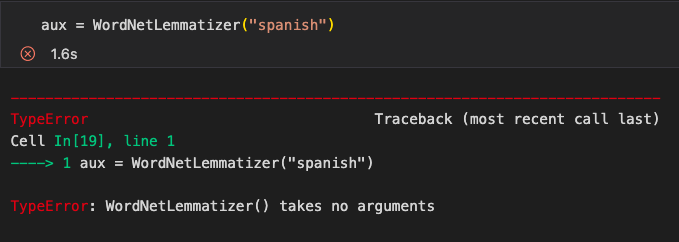

In [15]:
display(Image(filename='..\..\images\expected_error.png'))

Do not worry, the error shown above **IS NOT AN ERROR, IS AN IMAGE!**

> The function `lematizar_texto()` define as:
>
> ```
>   def lematizar_texto(texto):
>
>       palabras = nltk.word_tokenize(texto, language='spanish')
>
>       lemas = [lematizador.lemmatize(palabra) for palabra in palabras]
>
>       return ' '.join(lemas)
> ```
>
> Works as follows, the code:
> 
> ```
> palabras = nltk.word_tokenize(texto, language='spanish')
> ```
> 
> Is mapping each word in `texto` to it respective token defined in `/Users/eduardomorenoortiz/Desktop/ITAM/nanook/nlp_nanook/env_nlp_nanook/lib/> python3.11/site-packages/nltk/nltk_data/tokenizers/punkt/spanish.pickle`. 
> 
> In the final part:
> 
> ```
> lemas = [lematizador.lemmatize(palabra) for palabra in palabras]
> ```
> 
> Is lemmatizing words on Spanish using a model built to lemmatized text in English!
> 
> Now, do you see why the text was erroneous?
>
> [Here](https://stackoverflow.com/questions/60534999/how-to-solve-spanish-lemmatization-problems-with-spacy) an interesting chat about this issue.

The corrected function using `spaCy` is:

In [16]:
import spacy

In [17]:
spacy.__version__

'3.7.4'

In [18]:
nlp = spacy.load('es_core_news_lg')

In [19]:
def lematizar_texto(texto):
    lemas = nlp(texto)
    lematizado = [token.lemma_ for token in lemas]
    return ' '.join(lematizado)

In [20]:
print(f"Original text: {df_clean['Message_clean'][0]}")
print(f"Lemmatized  text: {lematizar_texto(texto=df_clean['Message_clean'][0])}")
print('-'*30)
print(f"Original text: {df_clean['Message_clean'][23]}")
print(f"Lemmatized  text: {lematizar_texto(texto=df_clean['Message_clean'][23])}")
print('-'*30)
print(f"Original text: nota como la palabra graves ahora tiene asociado el token graves")
print(f'Lemmatized  text: {lematizar_texto(texto="nota como la palabra graves ahora tiene asociado el token graves")}')

Original text: a los nacidos entre 1970 y 1987 somos una generacion especial y nos denominaron la generacion x y como no si nuestra infancia estuvo llena de cambios somos la ultima generacion que jugaba en la calle y en los recreos del colegio a las bolitas a el escondite somos la primera generacion que jugo con videojuegos fuimos a parques de atracciones y vimos caricaturas a color fuimos los ultimos en grabar canciones de la radio en casettes como olvidarlo si mientras se grababa en algunos casos no podiamos ni hablar y vimos peliculas en version beta y vhs pero orgullosos pioneros del personal stereo y los cd's cuantos no tuvimos que tragarnos salvado por la campana con todo y screech beverly hills 90210 nosotros vimos la caida de torres gemelas y tambien vimos caer el muro de berlin aprendimos a utilizar los ordenadores antes que nuestros padres y abuelos y sobre todo antes de todos esos ninos cerebritos de hoy en dia y nunca vimos a los que no sabian usar los ordenadores como una 

Be more patient, the following code will take more time to run (my machine finished in 4.5 hours aproximately!)

In [21]:
lemmatization = df_clean['Message_clean'].apply(lambda x: lematizar_texto(texto=x)) # Uncomment if first time running the notebook
df_clean['Message_clean_lemm'] = lemmatization # Uncomment if first time running the notebook

In [22]:
df_clean.to_pickle(r'..\..\..\data\preprocessed\stemm_lemm_text_nanook.pkl') # Uncomment if first time running the notebook

In [23]:
df_clean.to_csv(r'..\..\..\data\preprocessed\stemm_lemm_text_nanook.csv') # Uncomment if first time running the notebook

In [24]:
df_clean.head()

,index,Facebook Id,Likes at Posting,Post Created,Type,Total Interactions,Likes,Comments,Shares,Love,...,Message,Image Text,Link Text,Description,score,messageChar_length,messageWords_length,Message_clean,Message_clean_stemm,Message_clean_lemm
0,0,153630631414604,NaN,2016-01-05 20:55:17 CST,Photo,"7,836",7266,442,63,51,...,A LOS NACIDOS ENTRE 1970 Y 1987 Somos una gene...,NaN,NaN,NaN,36.28,4329,720,a los nacidos entre 1970 y 1987 somos una gene...,a los nac entre 1970 y 1987 som una gener espe...,a el nacido entre 1970 y 1987 ser uno generaci...
1,1,344760762323803,NaN,2018-03-25 20:22:33 CST,Photo,"12,530",2946,44,9025,357,...,PORQUE VOTARE POR GUSTAVO PETRO Hoy quiero com...,NaN,NaN,NaN,338.65,3577,603,porque votare por gustavo petro hoy quiero com...,porqu votar por gustav petr hoy quier compart ...,porque votare por gustavo petro hoy querer com...
2,2,663135523805166,NaN,2018-04-26 15:23:31 CDT,Photo,"3,727",2137,77,917,583,...,"Ministra de medio ambiente, a trabajar por el ...",NaN,NaN,NaN,29.12,100,16,ministra de medio ambiente a trabajar por el c...,ministr de medi ambient a trabaj por el cambi ...,ministra de medio ambiente a trabajar por el c...
3,3,461295120574213,NaN,2016-05-02 17:59:04 CDT,Photo,"3,146",2548,249,188,123,...,A LOS NACIDOS ENTRE 1970 Y 1987 Somos una gene...,NaN,NaN,NaN,22.31,4314,717,a los nacidos entre 1970 y 1987 somos una gene...,a los nac entre 1970 y 1987 som una gener espe...,a el nacido entre 1970 y 1987 ser uno generaci...
4,4,663135523805166,NaN,2016-06-28 23:41:26 CDT,Photo,"2,804",2367,57,181,87,...,AYÚDANOS A COMPARTIR LA IMAGEN.. Por tan magni...,NaN,NaN,NaN,21.91,517,72,ayudanos a compartir la imagen por tan magnicf...,ayudan a compart la imag por tan magnicf pot p...,ayudano a compartir el imagen por tanto magnic...


In [25]:
df_clean.shape

(1392634, 25)